# Modifying an existing Compocyte classifier.

In the previous tutorial, we labelled a PBMC dataset, fit an explicitly defined label (and thus classifier) hierarchy to our labels and trained a Compocyte classifier to assign cell type labels to new data. Now, we want to take a look at the ways in which a hierarchical classifier permits changes in a way a monolithic classifier would not.

We will start by loading the classifier we have previously trained.

In [1]:
from Compocyte.core.hierarchical_classifier import HierarchicalClassifier
import scanpy as sc

# Load the trained classifier by specifying a save_path and calling the load() method. 
# The save_path should be the same as the one used during training.
classifier = HierarchicalClassifier(
    save_path="./exclude/pbmc_classifier"
)
classifier.load()

Neither graph nor dict_of_cell_relations defined upon initialization.
Please run .load() to load an existing classifier.


/usr/local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
test_adata = sc.read_h5ad("./exclude/test_adata.h5ad")

We already know that we get predictions when running our classifier on this data, but let's see if they are any good.

In [3]:
classifier.load_adata(test_adata)
classifier.predict_all_child_nodes('Blood')

Predicting at Blood.
Predicting at Lymphoid.
Predicting at T cells.
Predicting at Myeloid.


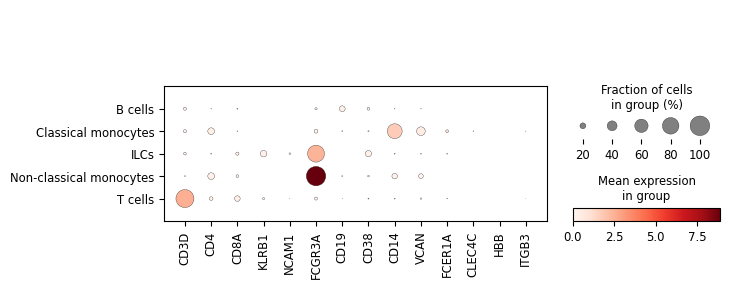

In [4]:
sc.pl.dotplot(
    classifier.adata, 
    var_names=['CD3D', 'CD4', 'CD8A', 'KLRB1', 'NCAM1', 'FCGR3A', 'CD19', 'CD38', 'CD14', 'VCAN', 'FCER1A', 'CLEC4C', 'HBB', 'ITGB3'], 
    groupby='Level_2_pred'
)

Not so bad for a classifier trained on 2000 cells. Let's assume that I am quite interested in the B cell subset. However, I did not have sufficient data to train the classifier beyond the B cell label. But someone else did.
We will now take the B cell branch of our the official pretrained PBMC classifier and attach it to the classifier we have trained here and see how it fares. 

This is our classifier before expanding.

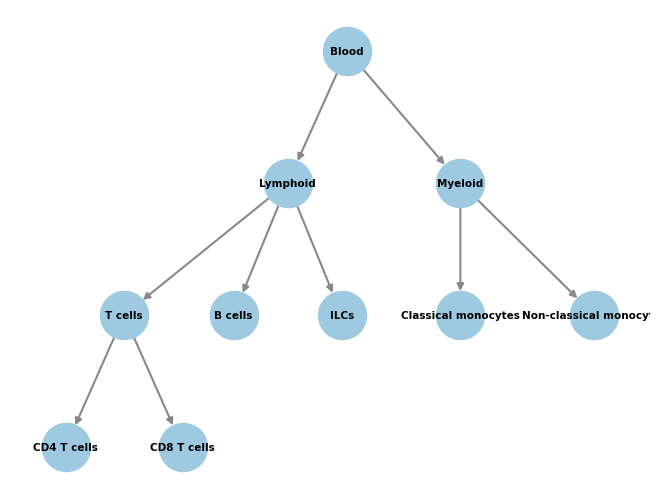

In [5]:
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

# Plot the graph structure we gave to the classifier during training.
pos = graphviz_layout(
    classifier.graph,prog="dot",
    root='Blood',
    args='-Gsplines=curved -Gnodesep=8 -Goverlap=scalexy -Gbeautify=false'
)
nx.draw(
    classifier.graph, pos,
    with_labels=True,
    node_color="#9ecae1",
    node_size=1200,
    edge_color="#888",
    width=1.5,
    font_size=7.5,
    font_weight="bold",
)

In [6]:
from Compocyte.pretrained import pbmc_pretrained

pretrained_classifier = pbmc_pretrained()

Neither graph nor dict_of_cell_relations defined upon initialization.
Please run .load() to load an existing classifier.


In [7]:
exported_pretrained = pretrained_classifier.export_classifiers("./exclude/exported_classifiers/")
exported_3k = classifier.export_classifiers("./exclude/exported_classifiers_3k/")

In [8]:
pretrained_classifier.dict_of_cell_relations

{'Blood': {'PL': {},
  'ERY': {},
  'MCP': {},
  'leukocyte': {'PB': {'B': {'B-naive': {},
     'B-memory': {'B-memory-DN': {},
      'B-memory-switched': {},
      'B-memory-non-switched': {}}},
    'plasma-blast': {'plasma-blast_proliferating': {},
     'plasma-blast_IgM': {},
     'plasma-blast_IgG': {},
     'plasma-blast_IgA': {}}},
   'M': {'gran': {'baso': {}, 'neutro': {}},
    'DC': {'AS-DC': {},
     'cDC': {'cDC1': {}, 'cDC2': {}, 'cDC3': {}},
     'p-DC': {}},
    'mono': {'i-mono': {'i-mono_IFN-I': {}},
     'mono_IFN-I': {},
     'c-mono': {'c-mono_IFN-I': {},
      'inf-c-mono': {},
      'c-mono_inflammasome': {}},
     'nc-mono': {'nc-mono_IFN-I': {}, 'nc-mono_inflammasome': {}}}},
   'TNK': {'TNK_proliferating': {},
    'ILC': {'NK': {'NK_proliferating': {},
      'CD56dim-NK': {},
      'CD56bright-NK': {},
      'NK-adaptive': {}},
     'ILC2': {}},
    'T': {'T_proliferating': {},
     'abT': {'abT_proliferating': {},
      'NKT': {},
      'CD4-T': {'CD4-T-naive':

In [9]:
exported_3k['Blood']['Lymphoid']['B'] = exported_pretrained['Blood']['leukocyte']['PB']['B']

In [10]:
# Remove duplicate B cell node from the new hierarchy to avoid confusion during merging.
del exported_3k['Blood']['Lymphoid']['B cells']

In [11]:
test_adata = sc.read_h5ad("./exclude/test_adata.h5ad")

In [12]:
merged_classifier = HierarchicalClassifier(
    save_path="./exclude/merged_classifier", 
    dict_of_cell_relations=exported_3k,
    adata=test_adata,
    # the new hierarchy goes one level deeper than the original one, so we need to add the new level to the obs_names
    obs_names=classifier.obs_names + ['Level_4'],
    temp_paths=["./exclude/exported_classifiers/", "./exclude/exported_classifiers_3k/"],
    root_node=classifier.root_node
)
# The label encoding is specified at the local classifier level. 
# Because we renamed the B cell node, we need to tell the classifier to update the label encoding as well.
merged_classifier.rename(old_label='B cells', new_label='B', parent_label='Lymphoid')

/workspaces/Compocyte/src/Compocyte/core/base/data_base.py:122: UserWarning: You have supplied normalized, log-transformed data. Please ensure that                  this is intended and data is normalized to 10_000 counts per cell prior                  to log1p transformation.
  warn('You have supplied normalized, log-transformed data. Please ensure that \


This is our classifier after expanding.

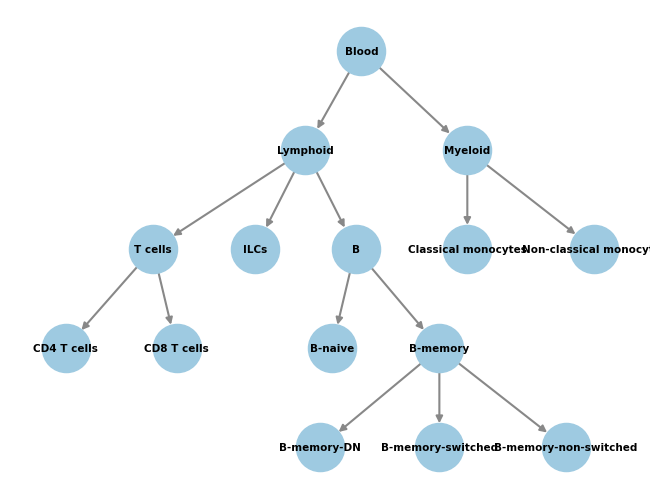

In [13]:
# Plot the graph structure we gave to the classifier during training.
pos = graphviz_layout(
    merged_classifier.graph,prog="dot",
    root='Blood',
    args='-Gsplines=curved -Gnodesep=8 -Goverlap=scalexy -Gbeautify=false'
)
nx.draw(
    merged_classifier.graph, pos,
    with_labels=True,
    node_color="#9ecae1",
    node_size=1200,
    edge_color="#888",
    width=1.5,
    font_size=7.5,
    font_weight="bold",
)

In [14]:
merged_classifier.predict_all_child_nodes('Blood')

Predicting at Blood.
Predicting at Lymphoid.
Predicting at T cells.
Predicting at B.
Predicting at B-memory.
Predicting at Myeloid.


/usr/local/lib/python3.14/site-packages/anndata/_core/anndata.py:1257: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.14/site-packages/anndata/_core/anndata.py:1257: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.14/site-packages/anndata/_core/anndata.py:1257: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.14/site-packages/anndata/_core/anndata.py:1257: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


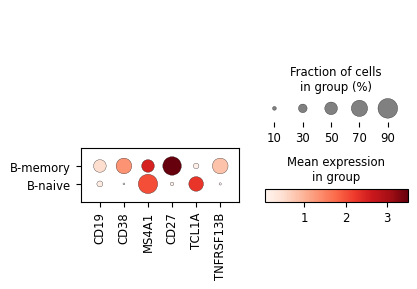

In [15]:
sc.pl.dotplot(
    merged_classifier.adata[merged_classifier.adata.obs.Level_2_pred == 'B'], 
    var_names=['CD19', 'CD38','MS4A1', 'CD27', 'TCL1A', 'TNFRSF13B'], 
    use_raw=True,
    groupby='Level_3_pred'
)

Would you look at that? With some Compocyte magic, we have found memory B cells that we could not have found without expanding the B cell classifier. Congratulations.
If you would like to learn more have a look at our other tutorials.